In [1]:
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
import plotting.plotting_style as plt

data = util.load_data(path_file='/Users/maxwernz/development/Data Literacy/data_csv/final_Data_iaaf_scores_neu_v2.csv')  

# data_adults = data[(data["altersklasse"] == "Frauen") | (data["altersklasse"] == "Maenner")]

In [2]:

disciplines = data['disziplin'].unique()

years = np.sort(data['jahr'].unique())

counts = {}

for d in disciplines:
    counts[d] = []
    for y in years:
        count = len(data[(data['disziplin'] == d) & (data['jahr'] == y)])
        counts[d].append(count)

table = pd.DataFrame(counts, index=years).T  # transpose to have disciplines as rows
table.columns.name = 'jahr'

table

jahr,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
100 m,336,322,327,327,330,303,314,311,355,325,...,341,342,360,360,324,401,402,398,398,404
200 m,298,286,303,307,311,327,278,296,325,316,...,314,331,361,355,323,397,402,401,386,399
400 m,356,355,353,355,353,358,364,363,360,363,...,360,360,357,362,352,391,392,396,390,391
800 m,348,349,344,344,353,350,358,359,356,360,...,357,361,355,363,356,390,391,397,371,381
1500 m,353,352,354,352,352,356,359,358,356,359,...,348,361,351,362,361,401,394,388,375,361
5000 m,237,211,245,236,235,243,251,245,254,247,...,243,259,246,260,254,300,289,293,298,292
10 000 m,127,118,129,131,117,123,128,121,146,132,...,120,152,140,143,120,163,151,153,163,162
10 km,158,159,156,160,157,160,163,159,160,157,...,146,169,158,163,161,199,197,196,201,173
Marathon,98,99,100,99,99,98,101,96,97,98,...,90,105,97,99,89,98,98,77,100,67
100 m Huerden,157,159,140,142,154,165,129,130,152,164,...,160,161,179,179,154,193,194,191,199,196


In [3]:
data[(data['disziplin'] == '400 m') & (data['jahr'] == 2017)].count()

jahr            360
geschlecht      360
altersklasse    360
disziplin       360
leistung        360
wind              0
name            360
geburtsjahr     360
verein          360
datum           360
ort             360
iaaf_score      360
group           360
dtype: int64

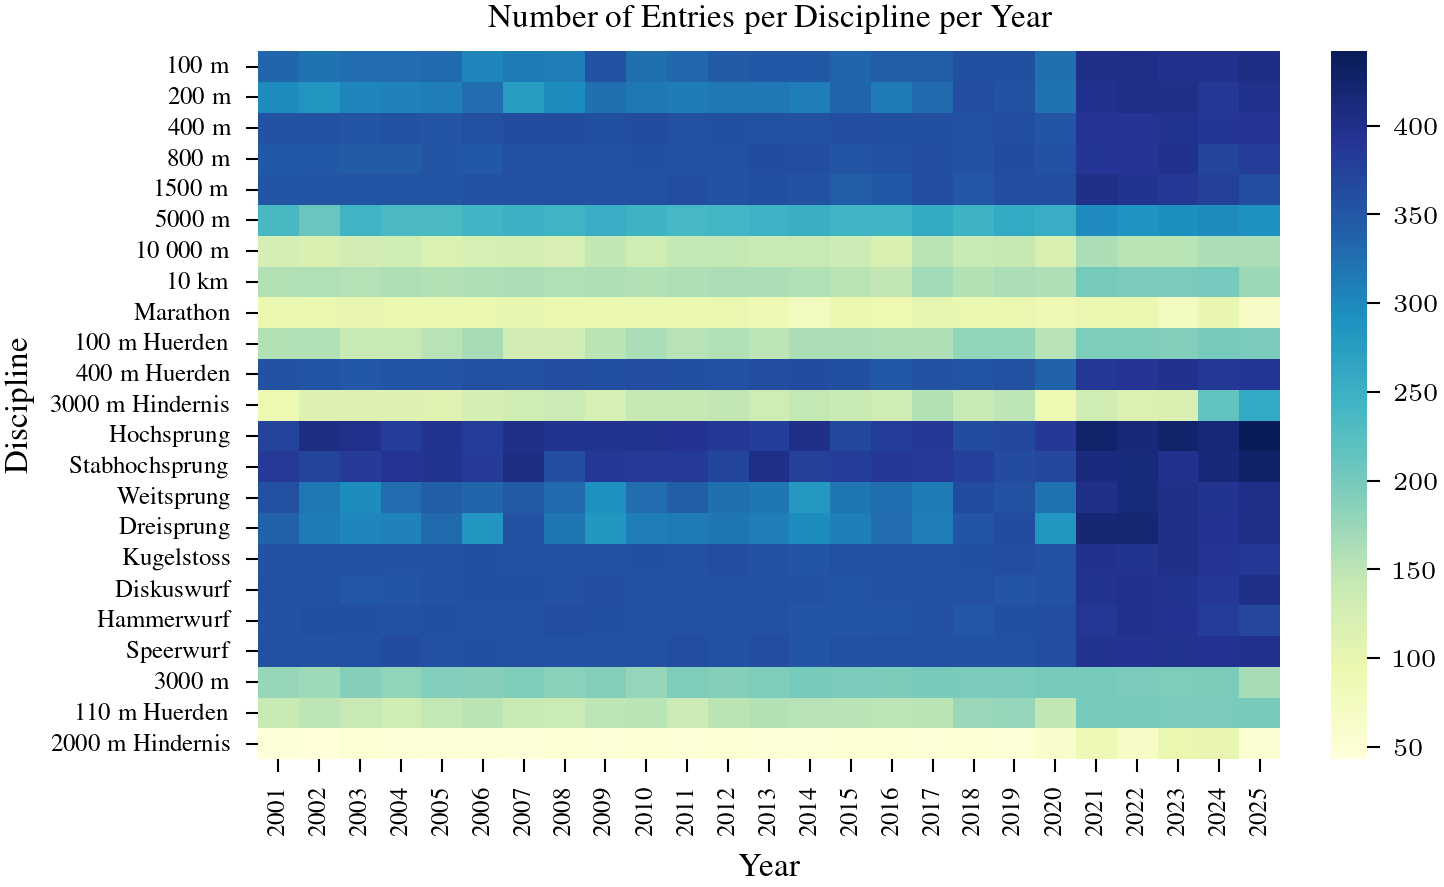

In [7]:
import seaborn as sns
# import matplotlib.pyplot as plt
plt.bundles.icml2024(column="full")
with plt.rc_context(plt.increase_figsize(1.5)):

# plt.figure(figsize=(10, 8))

# Draw heatmap
    ax = ax = sns.heatmap(table, fmt="d", cmap="YlGnBu")
    ax.set_yticks(np.arange(len(table.index)) + 0.5)  # Position der Labels korrigieren
    ax.set_yticklabels(table.index, rotation=0)       # Namen anzeigen, horizontal

    plt.title("Number of Entries per Discipline per Year")
    plt.ylabel("Discipline")
    plt.xlabel("Year")
    plt.show()